In [1]:
# notebook for testing out new TJ river flow maker...
import sys
import os
import subprocess
import shutil
import numpy as np
import netCDF4 as nc
import matplotlib.pyplot as plt
import gsw
import pickle
import glob
import urllib.request
from urllib.error import URLError, HTTPError


from datetime import datetime, timedelta, date

sys.path.append('../sdpm_py_util')
import init_funs_forecast as initfuns
import run_funs as runfuns
import util_functions as utilfuns
import river_functions as riverfuns
import ocn_funs_forecast as ocnfuns
import swan_functions as swanfuns
import run_funs as runfuns
sys.path.append('/home/mspydell/models/PFM_root/PFM/driver')
import driver_functions as driverfuns
#from driver_run_forecast_LV1234 import driver_run_fore_LV1234
from driver_run_pfm_phm import driver_run_pfm_phm


/home/mspydell/models/PFM_root/PFM/ipynb_files/../sdpm_py_util/ocn_functions.py:32: UserWarning: The seawater library is deprecated! Please use gsw instead.
  import seawater


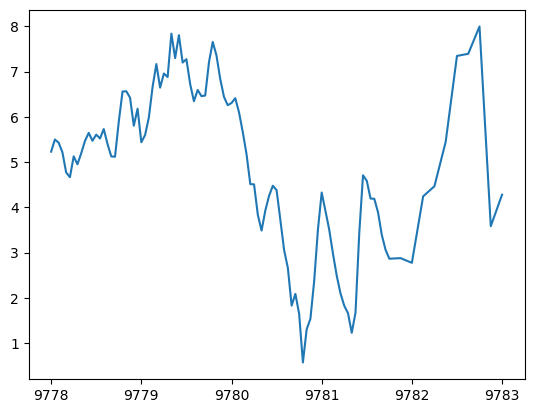

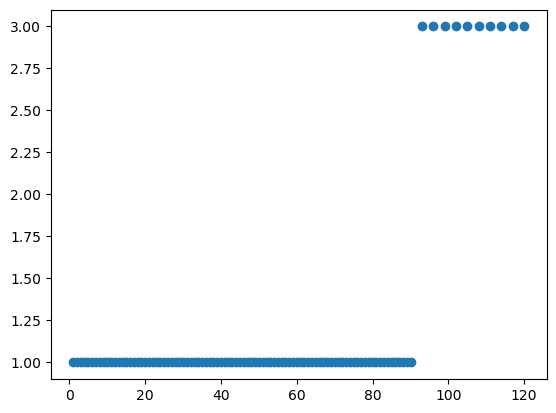

In [2]:
fn_atm = '/dataSIO/PFM_Simulations/Archive/Forcing/atm_ecmwf_LV4_2025100900.nc'
ds_atm = nc.Dataset(fn_atm)
lat = ds_atm.variables['lat'][:].data
lon = ds_atm.variables['lon'][:].data
u = ds_atm.variables['Uwind']
v = ds_atm.variables['Vwind']
t = ds_atm.variables['wind_time']
umag = np.sqrt( np.square(u) + np.square(v) )

fig, ax = plt.subplots()
plt.plot(t[:].data,umag[:,0,0])
#plt.plot(t,umag[:,-1,0])
#plt.plot(t,umag[:,0,-1])
#plt.plot(t,umag[:,-1,-1])
#print(np.diff(24*t[:].data))
#print(np.cumsum( np.diff(24*t[:].data)))
fig, ax = plt.subplots()
plt.plot(np.cumsum( np.diff(24*t[:].data)),np.diff(24*t[:].data),'o')



In [3]:
pkl_fnm = "/scratch/PFM_Simulations/forecast_info.pkl"
fout = "./swan_wind.txt"
u2,v2 = swanfuns.mk_swan_wnd_file(fout,pkl_fnm)


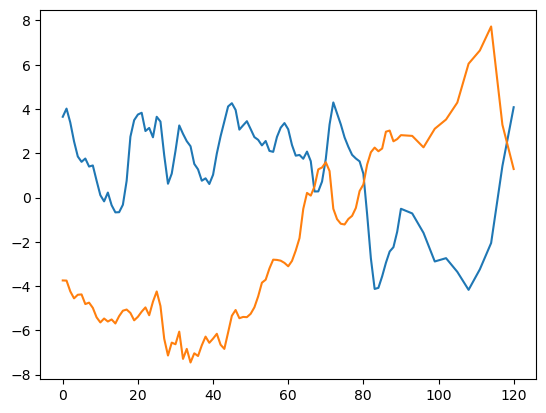

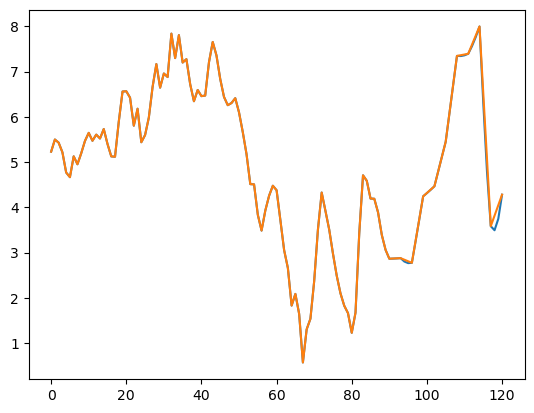

In [4]:
fig, ax = plt.subplots()
plt.plot(u2)
plt.plot(v2)

fig, ax = plt.subplots()
plt.plot(np.sqrt( np.square(u2) + np.square(v2) ))
t_hr = 24*t[:].data
t_hr = t_hr - t_hr[0]
plt.plot(24*(t[:].data - t[0].data),umag[:,0,0])


